# Music Genre Classification
### Classic ML + Deep Learning (ResNet-style CNN) Pipeline

## 1. Environment Setup

In [1]:
# Install dependencies
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost librosa tensorflow

  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl.metadata (16 kB)



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: C:\Users\USER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 2.6/101.7 MB 12.6 MB/s eta 0:00:08
   -- ------------------------------------- 6.6/101.7 MB 16.1 MB/s eta 0:00:06
   --- ------------------------------------ 10.0/101.7 MB 16.3 MB/s eta 0:00:06
   ----- ---------------------------------- 13.1/101.7 MB 16.1 MB/s eta 0:00:06
   ------ --------------------------------- 16.8/101.7 MB 16.5 MB/s eta 0:00:06
   ------- -------------------------------- 19.7/101.7 MB 16.3 MB/s eta 0:00:06
   -------- ------------------------------- 22.3/101.7 MB 15.7 MB/s eta 0:00:06
   --------- ------------------------------ 24.6/101.7 MB 15.0 MB/s eta 0:00:06
   ----------- ---------------------------- 28.0/101.7 MB 15.1 MB/s eta 0:00:05
   ----------- ---------------------------- 30.4/101.7 MB 14.6 MB/s eta 0:00:05
   ------------- -------------------------- 33.3/101.7 MB 14.6 MB/s eta 0:00:05
   -------------- ------------------------- 37.0/10

## 2. Imports

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from mpl_toolkits.mplot3d import Axes3D

import librosa
import librosa.display
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.image import resize

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 3. Load Tabular Feature Data

In [4]:
DATASET_ROOT = r"C:\Users\USER\Documents\music-genre-classification\Data"
GENRE_FOLDER = os.path.join(DATASET_ROOT, 'genres_original')
genre_list = os.listdir(GENRE_FOLDER)
print("Genres found:", genre_list)

# Load CSV feature file (assumed to be in DATASET_ROOT)
csv_path = os.path.join(DATASET_ROOT, 'features_30_sec.csv')  # update filename if needed
df = pd.read_csv(csv_path)
print(df.shape)
df.head()

Genres found: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
(1000, 60)


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


## 4. Exploratory Data Analysis

Dataset shape: (1000, 60)

Class distribution:
label
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
Name: count, dtype: int64


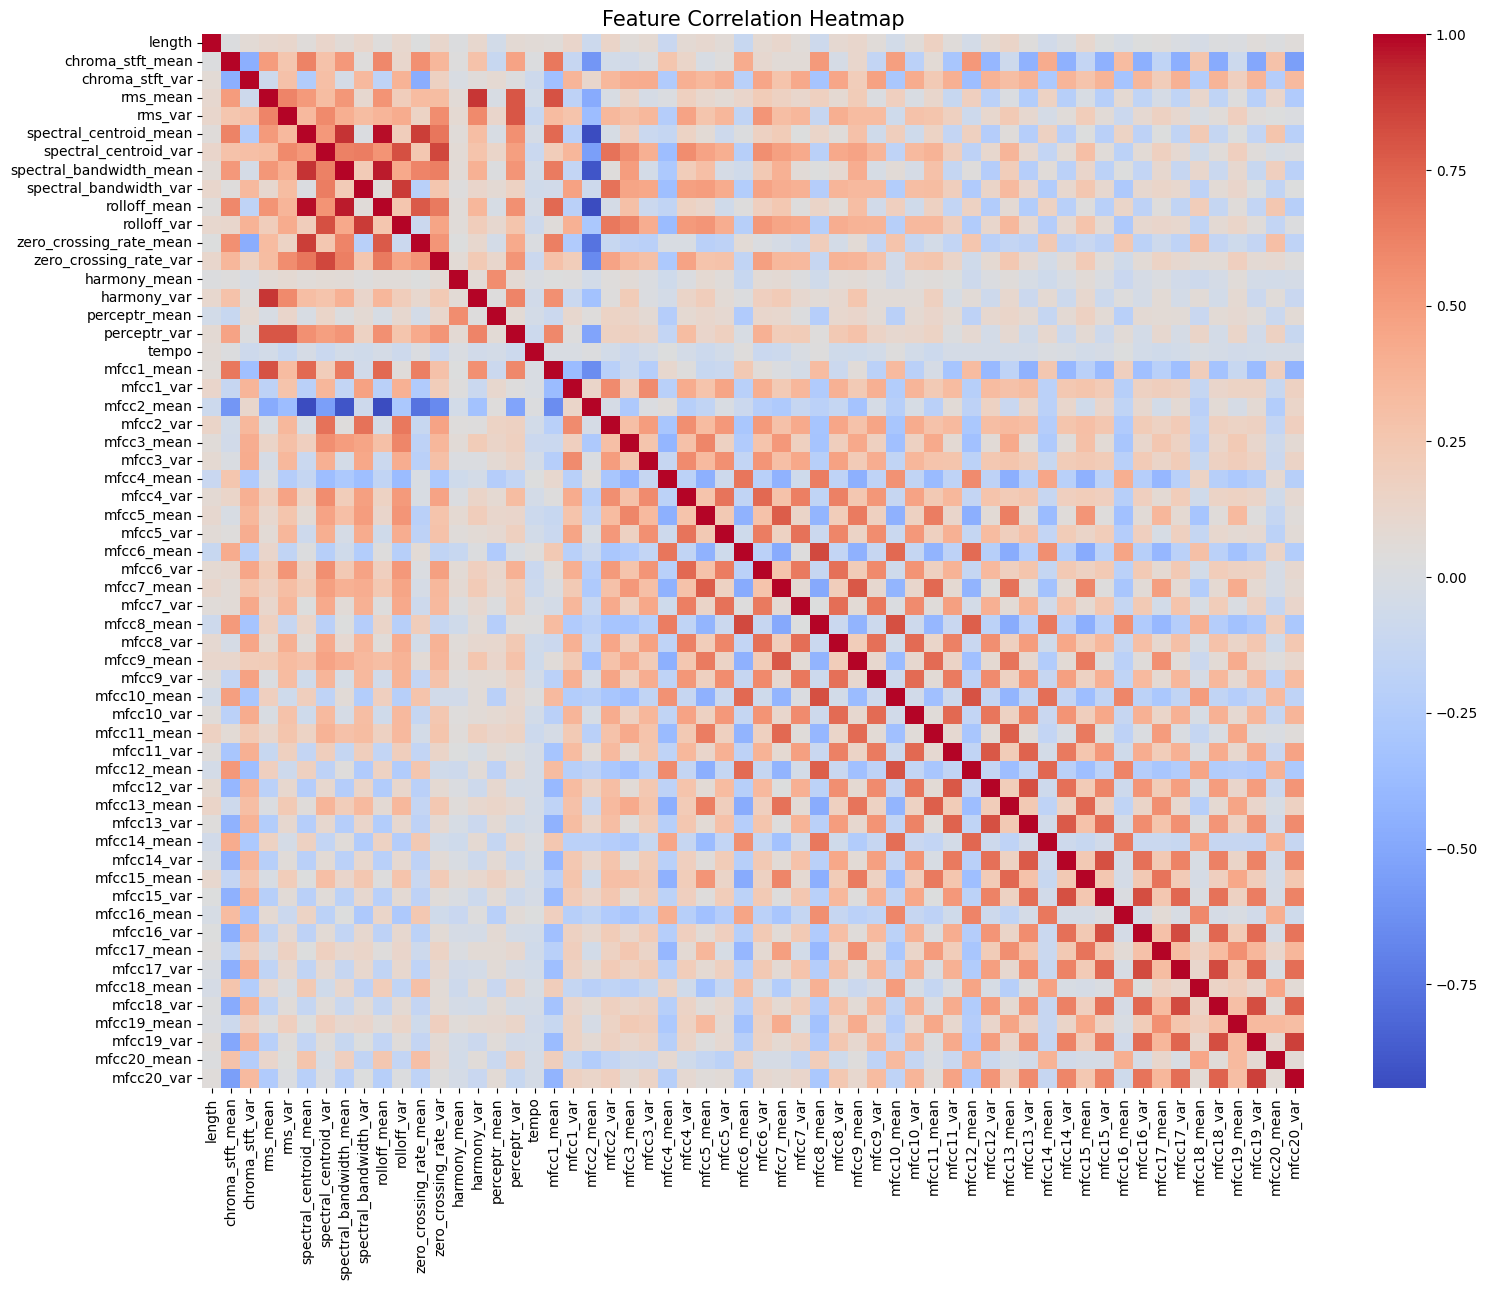


Top feature correlations with genre label:
genre_encoded              1.000000
spectral_bandwidth_mean    0.388800
rolloff_mean               0.385213
spectral_centroid_mean     0.378395
chroma_stft_mean           0.366451
mfcc1_mean                 0.340101
spectral_centroid_var      0.317572
rolloff_var                0.273637
zero_crossing_rate_var     0.272210
zero_crossing_rate_mean    0.268278
rms_mean                   0.213968
spectral_bandwidth_var     0.201332
mfcc9_mean                 0.198137
mfcc7_mean                 0.182958
perceptr_var               0.176769
mfcc12_mean                0.153867
mfcc4_var                  0.143586
mfcc11_mean                0.140996
harmony_var                0.123732
mfcc18_mean                0.119079
mfcc6_var                  0.119034
mfcc10_mean                0.116056
mfcc20_mean                0.113187
mfcc8_mean                 0.108619
rms_var                    0.107572
mfcc14_mean                0.088560
mfcc7_var           

C:\Users\USER\AppData\Local\Temp\ipykernel_26344\1188365255.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_tempo.values, y=avg_tempo.index, palette='magma', ax=ax)


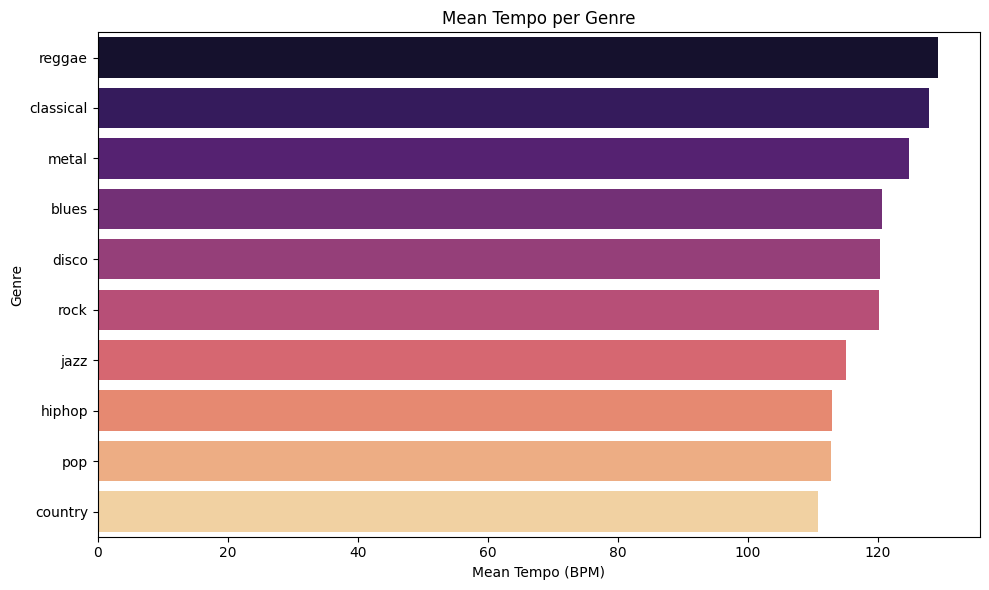

In [6]:
print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['label'].value_counts())

# Feature correlation heatmap
fig, ax = plt.subplots(figsize=(16, 13))
numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, ax=ax)
ax.set_title("Feature Correlation Heatmap", fontsize=15)
plt.tight_layout()
plt.show()

# Correlation of each feature with the genre label
df_copy = df.copy()
df_copy['genre_encoded'] = LabelEncoder().fit_transform(df_copy['label'])
label_corr = df_copy.corr(numeric_only=True)['genre_encoded'].sort_values(ascending=False)
print("\nTop feature correlations with genre label:")
print(label_corr)

# Average tempo per genre
avg_tempo = df.groupby('label')['tempo'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=avg_tempo.values, y=avg_tempo.index, palette='magma', ax=ax)
ax.set_xlabel("Mean Tempo (BPM)")
ax.set_ylabel("Genre")
ax.set_title("Mean Tempo per Genre")
plt.tight_layout()
plt.show()

## 5. Data Preparation Utility

In [9]:
SCALER_REGISTRY = {
    'standard': StandardScaler,
    'minmax':   MinMaxScaler,
    'robust':   RobustScaler,
}

def build_splits(
    feature_df,
    do_split=False,
    scaling='none',
    encode_target=False,
    holdout=0.2,
    rng=SEED
):
    """
    Construct feature matrix and target vector from a labelled DataFrame.

    Parameters
    ----------
    feature_df    : DataFrame containing a 'label' column.
    do_split      : When True, returns a stratified train/test split.
    scaling       : One of 'standard', 'minmax', 'robust', or 'none'.
    encode_target : Numerically encode the target labels.
    holdout       : Proportion of data reserved for testing.
    rng           : Random seed for reproducibility.

    Returns
    -------
    (X_train, X_test, y_train, y_test) if do_split else (X, y)
    """
    features = feature_df.select_dtypes(include='number')
    target   = feature_df['label']

    if encode_target:
        target = LabelEncoder().fit_transform(target)

    if not do_split:
        return features, target

    X_tr, X_te, y_tr, y_te = train_test_split(
        features, target,
        test_size=holdout,
        stratify=target,
        random_state=rng
    )

    scaler_cls = SCALER_REGISTRY.get(scaling)
    if scaler_cls:
        sc = scaler_cls()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

    return X_tr, X_te, y_tr, y_te

## 6. PCA Visualisation (3D)

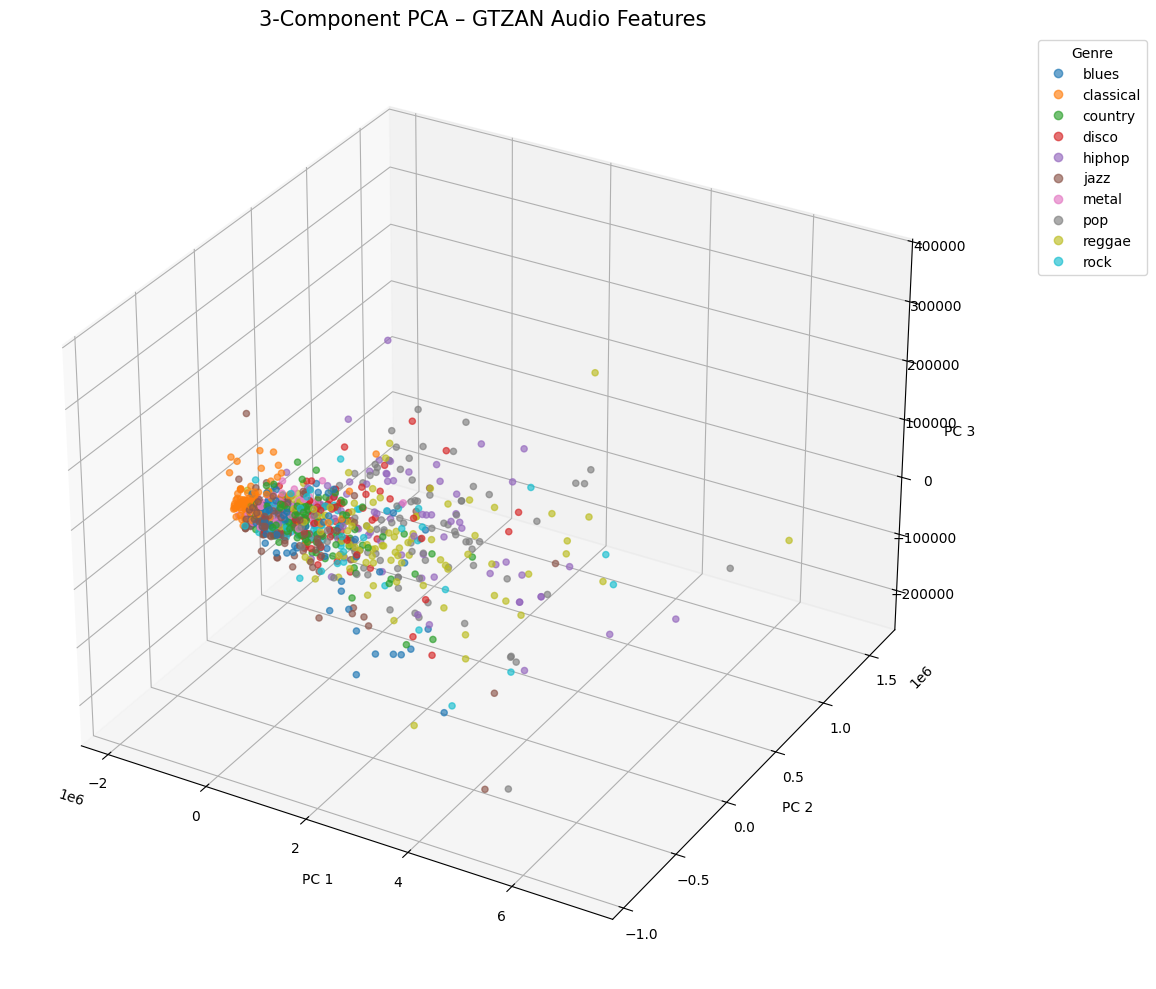

Explained variance per PC: [9.75834261e-01 2.33423936e-02 8.18405589e-04]


In [10]:
X_vis, y_vis = build_splits(df, do_split=False, scaling='standard', encode_target=True)

pca3 = PCA(n_components=3, random_state=SEED)
components = pca3.fit_transform(X_vis)

# Recover genre name strings for the legend
le_vis = LabelEncoder().fit(df['label'])
genre_names = le_vis.inverse_transform(y_vis)

fig = plt.figure(figsize=(13, 10))
ax3d = fig.add_subplot(111, projection='3d')
sc = ax3d.scatter(
    components[:, 0], components[:, 1], components[:, 2],
    c=pd.factorize(genre_names)[0], cmap='tab10', alpha=0.65
)
ax3d.set_title('3-Component PCA – GTZAN Audio Features', fontsize=15)
ax3d.set_xlabel('PC 1')
ax3d.set_ylabel('PC 2')
ax3d.set_zlabel('PC 3')

legend_handles, _ = sc.legend_elements(prop='colors')
unique_genres = list(pd.Series(genre_names).unique())
ax3d.legend(legend_handles, unique_genres, title='Genre',
            bbox_to_anchor=(1.08, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Explained variance per PC:", pca3.explained_variance_ratio_)

## 7. Classic ML Benchmark
> Models: Random Forest · SVM · k-NN · Logistic Regression · **XGBoost** (new)

In [11]:
def benchmark_classifiers(feature_df):
    """
    Train and evaluate a suite of classifiers on the tabular feature set.
    Each model uses its preferred scaling strategy.
    Returns a dict of {model_name: {accuracy, confusion_matrix, report}}.
    """
    classifier_config = {
        'Random Forest':      ('standard', RandomForestClassifier(n_estimators=200, random_state=SEED)),
        'SVM – RBF Kernel':   ('standard', SVC(kernel='rbf', C=10, gamma='scale', random_state=SEED)),
        'k-Nearest Neighbour':('minmax',   KNeighborsClassifier(n_neighbors=7, metric='euclidean')),
        'Logistic Regression':('standard', LogisticRegression(max_iter=2000, C=1.0, random_state=SEED)),
        'XGBoost':            ('standard', XGBClassifier(
                                               n_estimators=300,
                                               learning_rate=0.08,
                                               max_depth=6,
                                               subsample=0.8,
                                               colsample_bytree=0.8,
                                               use_label_encoder=False,
                                               eval_metric='mlogloss',
                                               random_state=SEED
                                           )),
    }

    outcomes = {}

    for clf_name, (scaler_type, clf) in classifier_config.items():
        print(f"\n>>> Training: {clf_name}  (scaling={scaler_type})")

        X_tr, X_te, y_tr, y_te = build_splits(
            feature_df,
            do_split=True,
            scaling=scaler_type,
            encode_target=True
        )

        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_te)

        acc    = accuracy_score(y_te, preds)
        cm     = confusion_matrix(y_te, preds)
        report = classification_report(y_te, preds, output_dict=True)

        outcomes[clf_name] = {'accuracy': acc, 'confusion_matrix': cm, 'report': report}

        print(f"    Accuracy : {acc:.4f}")
        print(classification_report(y_te, preds))
        print('-' * 65)

    return outcomes

In [12]:
ml_results = benchmark_classifiers(df)


>>> Training: Random Forest  (scaling=standard)
    Accuracy : 0.7800
              precision    recall  f1-score   support

           0       0.83      0.75      0.79        20
           1       0.83      0.95      0.88        20
           2       0.70      0.80      0.74        20
           3       0.75      0.60      0.67        20
           4       0.67      0.80      0.73        20
           5       0.76      0.80      0.78        20
           6       0.89      0.85      0.87        20
           7       0.85      0.85      0.85        20
           8       0.76      0.80      0.78        20
           9       0.80      0.60      0.69        20

    accuracy                           0.78       200
   macro avg       0.78      0.78      0.78       200
weighted avg       0.78      0.78      0.78       200

-----------------------------------------------------------------

>>> Training: SVM – RBF Kernel  (scaling=standard)
    Accuracy : 0.7650
              precision    rec

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\training.py:200: UserWarning: [18:51:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


    Accuracy : 0.8000
              precision    recall  f1-score   support

           0       0.74      0.85      0.79        20
           1       0.95      0.95      0.95        20
           2       0.70      0.80      0.74        20
           3       0.76      0.65      0.70        20
           4       0.75      0.75      0.75        20
           5       0.78      0.90      0.84        20
           6       0.89      0.85      0.87        20
           7       0.82      0.90      0.86        20
           8       0.81      0.85      0.83        20
           9       0.83      0.50      0.62        20

    accuracy                           0.80       200
   macro avg       0.80      0.80      0.80       200
weighted avg       0.80      0.80      0.80       200

-----------------------------------------------------------------


## 8. Summary of Classic ML Results


  Random Forest
  Accuracy        : 0.7800
  Macro F1-Score  : 0.7780
  Macro Recall    : 0.7800
  Confusion Matrix:
[[15  0  3  0  0  1  0  0  1  0]
 [ 0 19  0  0  0  1  0  0  0  0]
 [ 0  0 16  0  0  1  0  0  1  2]
 [ 0  1  1 12  5  0  1  0  0  0]
 [ 1  0  0  1 16  0  1  0  0  1]
 [ 1  3  0  0  0 16  0  0  0  0]
 [ 0  0  0  2  0  0 17  0  1  0]
 [ 0  0  0  0  1  0  0 17  2  0]
 [ 0  0  0  0  1  0  0  3 16  0]
 [ 1  0  3  1  1  2  0  0  0 12]]

  SVM – RBF Kernel
  Accuracy        : 0.7650
  Macro F1-Score  : 0.7643
  Macro Recall    : 0.7650
  Confusion Matrix:
[[17  0  1  0  0  1  0  0  1  0]
 [ 0 17  0  0  0  3  0  0  0  0]
 [ 1  0 17  0  0  0  0  0  1  1]
 [ 0  1  0 11  1  0  1  3  1  2]
 [ 0  0  0  2 16  0  0  1  1  0]
 [ 1  2  0  0  0 17  0  0  0  0]
 [ 3  0  0  1  0  0 16  0  0  0]
 [ 0  2  0  1  0  0  0 14  3  0]
 [ 0  1  0  1  1  0  0  0 15  2]
 [ 0  0  2  1  0  1  0  2  1 13]]

  k-Nearest Neighbour
  Accuracy        : 0.7000
  Macro F1-Score  : 0.7009
  Macro Recall    : 0.

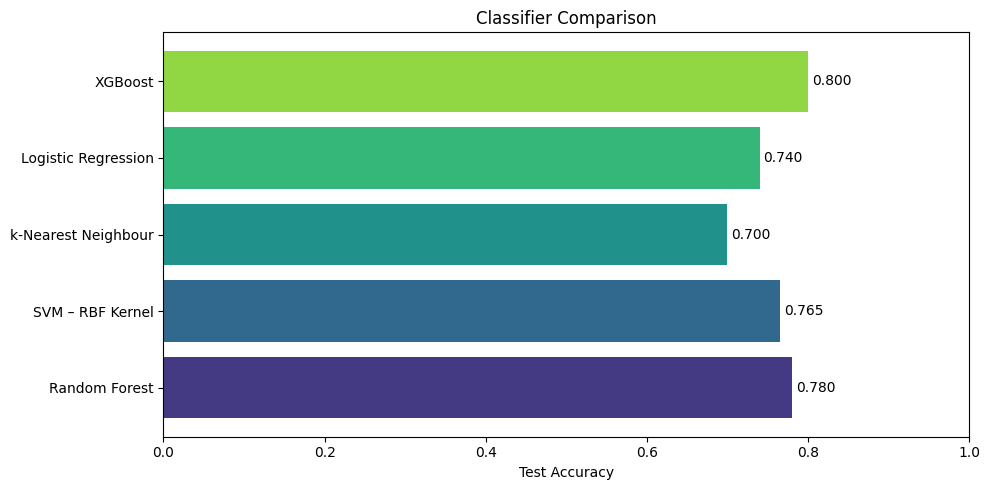

In [13]:
for clf_name, metrics in ml_results.items():
    rpt = metrics['report']
    print(f"\n{'='*50}")
    print(f"  {clf_name}")
    print(f"  Accuracy        : {metrics['accuracy']:.4f}")
    print(f"  Macro F1-Score  : {rpt['macro avg']['f1-score']:.4f}")
    print(f"  Macro Recall    : {rpt['macro avg']['recall']:.4f}")
    print("  Confusion Matrix:")
    print(metrics['confusion_matrix'])
    print('='*50)

# Bar chart comparison
names = list(ml_results.keys())
accs  = [ml_results[n]['accuracy'] for n in names]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(names, accs, color=sns.color_palette('viridis', len(names)))
ax.set_xlim(0, 1.0)
ax.set_xlabel('Test Accuracy')
ax.set_title('Classifier Comparison')
for bar, val in zip(bars, accs):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')
plt.tight_layout()
plt.show()

## 9. Deep Learning: ResNet-Inspired CNN
The architecture replaces the plain sequential CNN with **residual blocks**:
each block adds its input directly to the convolution output (skip connection),
enabling deeper networks without vanishing gradients.

### 9a. Audio Loading & Mel-Spectrogram Extraction

In [14]:
GENRES       = ['blues', 'classical', 'country', 'disco',
                'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
AUDIO_DIR    = r"C:\Users\USER\Documents\music-genre-classification\Data\genres_original"
IMG_SHAPE    = (128, 128)
SEG_SECONDS  = 3
OVERLAP_SEC  = 1


def audio_to_melspec(signal, sample_rate, output_shape=IMG_SHAPE):
    """Convert a raw audio segment to a resized log-mel spectrogram."""
    mel = librosa.feature.melspectrogram(y=signal, sr=sample_rate, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_tensor = tf.image.resize(
        np.expand_dims(mel_db, axis=-1), output_shape
    )
    return mel_tensor.numpy()


def ingest_audio_segments(
    audio_root, class_names,
    seg_dur=SEG_SECONDS, hop_dur=None, target_shape=IMG_SHAPE
):
    """
    Walk the genre directories, slice each file into overlapping segments,
    extract mel spectrograms and collect integer class labels.
    """
    if hop_dur is None:
        hop_dur = seg_dur - OVERLAP_SEC

    spectrogram_list, label_list = [], []

    for cls_idx, genre_name in enumerate(class_names):
        genre_path = os.path.join(audio_root, genre_name)
        print(f"  Loading {genre_name} …")

        for wav_file in os.listdir(genre_path):
            if not wav_file.endswith('.wav'):
                continue
            full_path = os.path.join(genre_path, wav_file)
            try:
                audio, sr = librosa.load(full_path, sr=22_050)
                seg_len  = seg_dur * sr
                hop_len  = hop_dur * sr

                for offset in range(0, len(audio) - seg_len, hop_len):
                    chunk = audio[offset: offset + seg_len]
                    spec  = audio_to_melspec(chunk, sr, target_shape)
                    spectrogram_list.append(spec)
                    label_list.append(cls_idx)
            except Exception as exc:
                print(f"    Skipped {wav_file}: {exc}")

    return np.array(spectrogram_list), np.array(label_list)

In [15]:
spectrograms, raw_labels = ingest_audio_segments(AUDIO_DIR, GENRES)
print("Spectrogram array shape :", spectrograms.shape)
print("Label array shape       :", raw_labels.shape)

# One-hot encode targets
one_hot_labels = to_categorical(raw_labels, num_classes=len(GENRES))

X_cnn_train, X_cnn_test, y_cnn_train, y_cnn_test = train_test_split(
    spectrograms, one_hot_labels,
    test_size=0.25,
    random_state=SEED,
    stratify=one_hot_labels
)

print(f"Train: {X_cnn_train.shape}  |  Test: {X_cnn_test.shape}")

  Loading blues …
  Loading classical …
  Loading country …
  Loading disco …
  Loading hiphop …
  Loading jazz …


C:\Users\USER\AppData\Local\Temp\ipykernel_26344\631465101.py:41: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(full_path, sr=22_050)
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


    Skipped jazz.00054.wav: 
  Loading metal …
  Loading pop …
  Loading reggae …
  Loading rock …
Spectrogram array shape : (13986, 128, 128, 1)
Label array shape       : (13986,)
Train: (10489, 128, 128, 1)  |  Test: (3497, 128, 128, 1)


### 9b. Residual Block & Model Definition

In [16]:
def residual_block(x, filters, kernel=(3, 3), downsample=False):
    """
    A residual (skip-connection) block.

    If `downsample=True` the spatial resolution is halved via stride-2
    convolution, and the shortcut is projected to the same shape.
    """
    stride = (2, 2) if downsample else (1, 1)

    # Main path
    out = layers.Conv2D(filters, kernel, strides=stride, padding='same')(x)
    out = layers.BatchNormalization()(out)
    out = layers.Activation('relu')(out)

    out = layers.Conv2D(filters, kernel, strides=(1, 1), padding='same')(out)
    out = layers.BatchNormalization()(out)

    # Shortcut path – project if shape changes
    if downsample or x.shape[-1] != filters:
        x = layers.Conv2D(filters, (1, 1), strides=stride, padding='same')(x)
        x = layers.BatchNormalization()(x)

    out = layers.Add()([out, x])
    out = layers.Activation('relu')(out)
    return out


def assemble_resnet_cnn(input_shape=(128, 128, 1), num_classes=10):
    """
    a lightweight ResNet-inspired CNN for mel-spectrogram classification.

    Architecture summary
    --------------------
    Input → Stem Conv → ResBlock×2 (32f) → ResBlock×2 (64f, ↓) →
    ResBlock×2 (128f, ↓) → GlobalAvgPool → Dense(256) → Dropout → Softmax
    """
    inp = Input(shape=input_shape)

    # Stem
    x = layers.Conv2D(32, (7, 7), strides=(2, 2), padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    # Stage 1 – 32 filters, same resolution
    x = residual_block(x, filters=32)
    x = residual_block(x, filters=32)

    # Stage 2 – 64 filters, spatial ↓
    x = residual_block(x, filters=64, downsample=True)
    x = residual_block(x, filters=64)

    # Stage 3 – 128 filters, spatial ↓
    x = residual_block(x, filters=128, downsample=True)
    x = residual_block(x, filters=128)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.45)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inp, outputs=out, name='ResNet_MelCNN')


res_cnn = assemble_resnet_cnn(input_shape=(*IMG_SHAPE, 1), num_classes=len(GENRES))
res_cnn.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
res_cnn.summary()

Model: "ResNet_MelCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 128, 128, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 64, 64, 32)        │           1,600 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 64, 64, 32)        │             128 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 64, 64, 32)        │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 32, 32, 32)        │               0 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 32, 32, 32)        │           9,248 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 32, 32, 32)        │             128 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 32, 32, 32)        │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 32, 32, 32)        │           9,248 │ activation_1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 32, 32, 32)        │             128 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 32, 32, 32)        │               0 │ batch_normalization_2[0][… │
│                               │                           │                 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_2 (Activation)     │ (None, 32, 32, 32)        │               0 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 32, 32, 32)        │           9,248 │ activation_2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 32, 32, 32)        │             128 │ conv2d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_3 (Activation)     │ (None, 32, 32, 32)        │               

 Total params: 734,986 (2.80 MB)

 Trainable params: 732,746 (2.80 MB)

 Non-trainable params: 2,240 (8.75 KB)

### 9c. Training

In [17]:
early_stop = EarlyStopping(
    monitor='val_accuracy', patience=7,
    restore_best_weights=True, verbose=1
)
lr_decay = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=4, min_lr=1e-6, verbose=1
)

train_history = res_cnn.fit(
    X_cnn_train, y_cnn_train,
    validation_data=(X_cnn_test, y_cnn_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, lr_decay]
)

Epoch 1/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 64s 174ms/step - accuracy: 0.5490 - loss: 1.2836 - val_accuracy: 0.1787 - val_loss: 4.2576 - learning_rate: 5.0000e-04
Epoch 2/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 60s 182ms/step - accuracy: 0.7263 - loss: 0.8107 - val_accuracy: 0.5530 - val_loss: 1.3654 - learning_rate: 5.0000e-04
Epoch 3/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 59s 180ms/step - accuracy: 0.7897 - loss: 0.6241 - val_accuracy: 0.4858 - val_loss: 1.7772 - learning_rate: 5.0000e-04
Epoch 4/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 60s 183ms/step - accuracy: 0.8329 - loss: 0.4874 - val_accuracy: 0.4338 - val_loss: 2.3857 - learning_rate: 5.0000e-04
Epoch 5/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 63s 192ms/step - accuracy: 0.8714 - loss: 0.3865 - val_accuracy: 0.5702 - val_loss: 1.8313 - learning_rate: 5.0000e-04
Epoch 6/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.8803 - loss: 0.3496 
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
328/328 ━━━━━━━━━━━━━━━━━━━━ 61s 187ms/s

### 9d. Evaluation & Visualisation

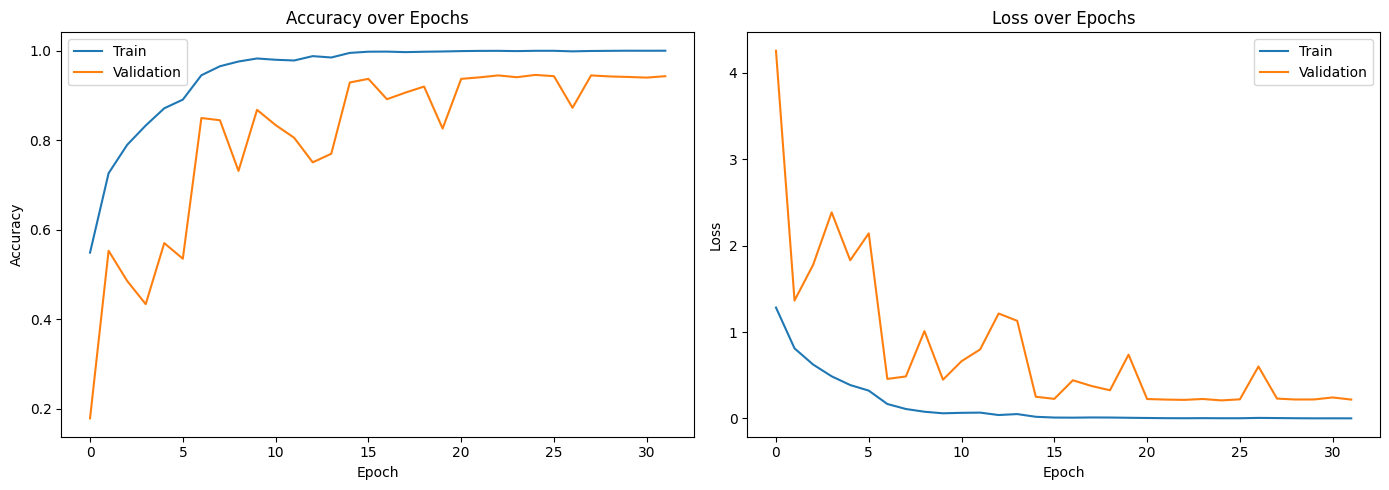

Final training accuracy   : 1.0000
Final validation accuracy : 0.9431
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step

Classification Report:
              precision    recall  f1-score   support

       blues       0.95      0.96      0.96       350
   classical       0.95      0.99      0.97       350
     country       0.93      0.92      0.92       350
       disco       0.96      0.94      0.95       350
      hiphop       0.95      0.97      0.96       350
        jazz       0.96      0.95      0.95       347
       metal       0.97      0.97      0.97       350
         pop       0.94      0.95      0.95       350
      reggae       0.97      0.93      0.95       350
        rock       0.88      0.87      0.87       350

    accuracy                           0.95      3497
   macro avg       0.95      0.95      0.95      3497
weighted avg       0.95      0.95      0.95      3497



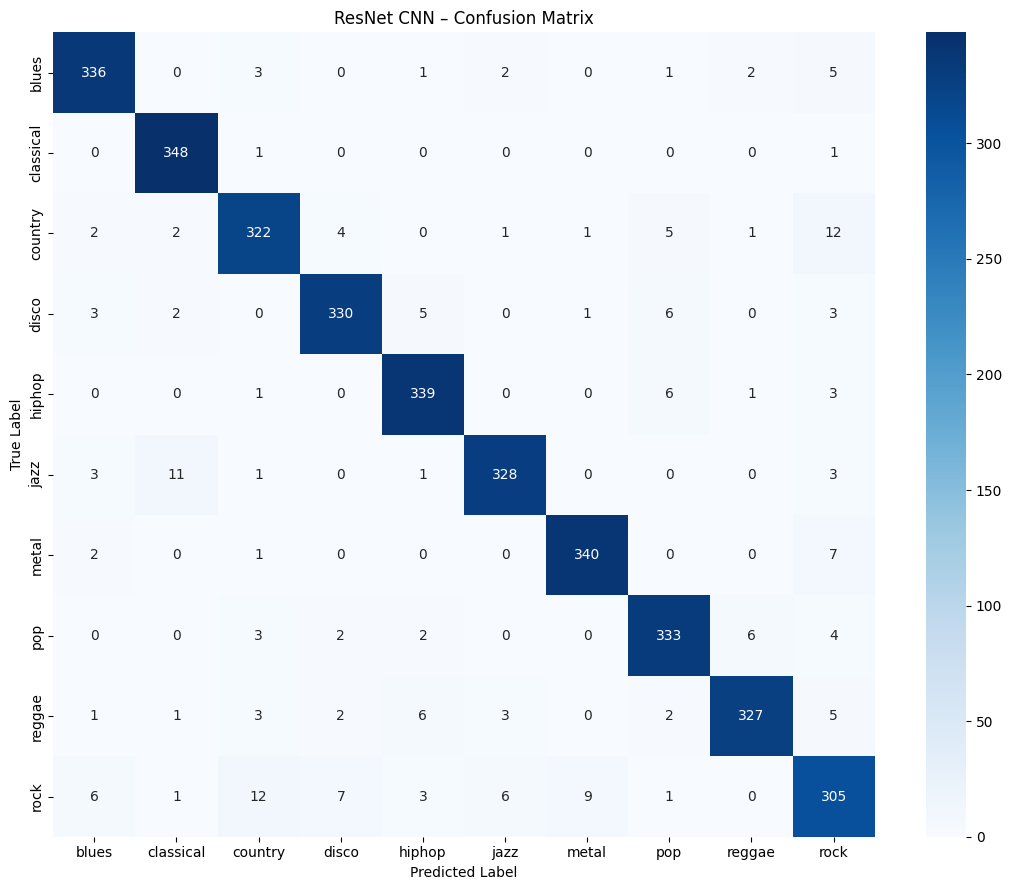

In [18]:
# Learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_history.history['accuracy'],    label='Train')
ax1.plot(train_history.history['val_accuracy'],label='Validation')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(train_history.history['loss'],    label='Train')
ax2.plot(train_history.history['val_loss'],label='Validation')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend()
plt.tight_layout()
plt.show()

# Final metrics
final_tr_acc = train_history.history['accuracy'][-1]
final_va_acc = train_history.history['val_accuracy'][-1]
print(f"Final training accuracy   : {final_tr_acc:.4f}")
print(f"Final validation accuracy : {final_va_acc:.4f}")

# Per-class report
cnn_probs   = res_cnn.predict(X_cnn_test)
cnn_pred_cls = np.argmax(cnn_probs, axis=1)
cnn_true_cls = np.argmax(y_cnn_test, axis=1)
print("\nClassification Report:")
print(classification_report(cnn_true_cls, cnn_pred_cls, target_names=GENRES))

# Confusion matrix
cnn_cm = confusion_matrix(cnn_true_cls, cnn_pred_cls)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GENRES, yticklabels=GENRES, ax=ax)
ax.set_title('ResNet CNN – Confusion Matrix')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### 9e. Save Model

In [19]:
res_cnn.save('genre_resnet_cnn.h5')
print('Model saved to genre_resnet_cnn.h5')

Model saved to genre_resnet_cnn.h5
